<a href="https://colab.research.google.com/github/Cairo-Henrique/Star-Galaxy-Classification/blob/main/CNN_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

torch.cuda.is_available()

True

In [ ]:
!gdown https://drive.google.com/uc?id=1dBGUzzqFnheL7SbWc4X0mneltdw49JTZ -O archive.zip

Downloading...
From: https://drive.google.com/uc?id=1dBGUzzqFnheL7SbWc4X0mneltdw49JTZ
To: /content/archive.zip
100% 8.88M/8.88M [00:00<00:00, 23.7MB/s]


In [ ]:
import zipfile
import os

# Define the path to the zip file
zip_file_path = 'archive.zip'

# Define the directory where you want to extract the contents
extraction_dir = 'archive'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_dir)

print(f"'{zip_file_path}' unzipped to '{extraction_dir}'")

'archive.zip' unzipped to 'archive'


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from pathlib import Path
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
import os # Para usar Path(os.getcwd()) no Colab
from PIL import Image, ImageEnhance, ImageOps # Import ImageOps for flipping

# Caminho para a pasta raiz do projeto (onde o script está)
# base_dir = Path(__file__).resolve().parent # This line causes an error in Colab
base_dir = Path(os.getcwd()) # Use the current working directory instead

# Caminhos para as imagens, relativos à pasta do scstar.
galaxy = base_dir / 'archive' / 'Cutout Files' / 'galaxy'
star = base_dir / 'archive' / 'Cutout Files' / 'star'

# Lista apenas os arquivos (não diretórios)
nomes_galaxy = [f.name for f in galaxy.iterdir() if f.is_file()]
coluna_class = [1] * len(nomes_galaxy)

nomes_star = [f.name for f in star.iterdir() if f.is_file()]
coluna_class += [0] * len(nomes_star)

# Cria o DataFrame
df = pd.DataFrame(nomes_galaxy + nomes_star, columns=['nome_imagem'])
df['classe'] = coluna_class

# Exibir as primeiras linhas do DataFrame
print(df.head())

# Data augmentation
use_data_augmentation = True

if use_data_augmentation:
    print("Applying data augmentation...")
    augmented_images = []
    augmented_labels = []

    # Define augmentation functions
    def rotate_image(image):
        angle = np.random.choice([0, 90, 180, 270])
        return image.rotate(angle) # Rotate by a random angle

    def flip_image(image):
        return ImageOps.mirror(image) # Flip horizontally

    # Apply augmentations to training data
    for index, row in df.iterrows():
        image_name = row['nome_imagem']
        label = row['classe']

        # Load the image
        if image_name in nomes_galaxy:
            image_path = base_dir / 'archive' / 'Cutout Files' / 'galaxy' / image_name
        elif image_name in nomes_star:
            image_path = base_dir / 'archive' / 'Cutout Files' / 'star' / image_name
        else:
            continue # Skip if image not found

        img = Image.open(image_path).convert('L') # Convert to grayscale

        # Add original image
        augmented_images.append(image_name)
        augmented_labels.append(label)

        # Apply augmentations with a probability
        if np.random.rand() > 0.5: # 50% chance to rotate
            augmented_img = rotate_image(img)
            augmented_images.append(f"rotated_{image_name}")
            augmented_labels.append(label)
            # Save augmented image temporarily to process later
            augmented_img.save(base_dir / 'archive' / 'Cutout Files' / ('galaxy' if label == 1 else 'star') / f"rotated_{image_name}")

        if np.random.rand() > 0.5: # 50% chance to flip
            augmented_img = flip_image(img)
            augmented_images.append(f"flipped_{image_name}")
            augmented_labels.append(label)
            # Save augmented image temporarily to process later
            augmented_img.save(base_dir / 'archive' / 'Cutout Files' / ('galaxy' if label == 1 else 'star') / f"flipped_{image_name}")

    # Create a new DataFrame with augmented data
    df_augmented = pd.DataFrame({'nome_imagem': augmented_images, 'classe': augmented_labels})
    df = df_augmented # Use the augmented DataFrame

    # Update nomes_galaxy and nomes_star with augmented image names
    nomes_galaxy = [name for name, label in zip(df['nome_imagem'], df['classe']) if label == 1]
    nomes_star = [name for name, label in zip(df['nome_imagem'], df['classe']) if label == 0]

# Salvar o DataFrame em um arquivo CSV
df.to_csv('star_galaxy_class.csv', index=False)

def show(nome_imagem):
    # Caminho para a imagem
    if nome_imagem in nomes_galaxy:
        image_path = base_dir / 'archive' / 'Cutout Files' / 'galaxy' / nome_imagem
    elif nome_imagem in nomes_star:
        image_path = base_dir / 'archive' / 'Cutout Files' / 'star' / nome_imagem
    else:
        print(f"Imagem {nome_imagem} não encontrada.")
        return

    # Lê a imagem
    img = mpimg.imread(image_path)

    # Exibe a imagem
    plt.imshow(img)
    plt.axis('off')  # Esconde os eixos
    plt.title(nome_imagem)
    plt.show()

#show('IC3521-H01_1419_1705_6.jpg')

# Criar arrays
X = np.array(df['nome_imagem'])
y = np.array(df['classe'])

# Dividir os dados em treino, validação e teste (exemplo: 80% treino, 10% validação, 10% teste)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

X_test_copy = X_test # Manter uma cópia dos nomes das imagens de teste

# Ver quantas imagens há em cada conjunto
print(f'Treinamento: {len(X_train)} imagens')
print(f'Validação: {len(X_val)} imagens')
print(f'Teste: {len(X_test)} imagens')

# Converter imagens para vetores de 64 pixels
from PIL import Image

# Função para vetorizar a imagem
def vetorizar(nome_imagem):
    if nome_imagem in nomes_galaxy:
        caminho = galaxy / nome_imagem
    else:
        caminho = star / nome_imagem
    img = Image.open(caminho).convert('L')  # tons de cinza
    #img = img.resize((8, 8)) # Redimensiona para 8x8 pixels
    img = np.array(img)
    #img = np.append(img, np.mean(img))  # Adiciona a média dos pixels como um recurso extra
    return img.flatten() / 255.0

# Vetorizar as imagens de treino, validação e teste
X_train = np.array([vetorizar(nome) for nome in X_train])
X_val = np.array([vetorizar(nome) for nome in X_val])
X_test = np.array([vetorizar(nome) for nome in X_test])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

                             nome_imagem  classe
0      J1603p3002_001_010_103_1289_3.jpg       1
1      J1252p2640_r_01_10_1609_880_3.jpg       1
2  J142943p385931_001_001_1891_152_3.jpg       1
3  J140012p353930_001_001_1931_678_3.jpg       1
4  J125219p264053_001_010_925_1504_3.jpg       1
Applying data augmentation...
Treinamento: 6408 imagens
Validação: 801 imagens
Teste: 802 imagens


Epoch 10, Training Loss: 0.5536, Validation Loss: 0.5558
Epoch 20, Training Loss: 0.5579, Validation Loss: 0.5577
Epoch 30, Training Loss: 0.5522, Validation Loss: 0.5517
Epoch 40, Training Loss: 0.5483, Validation Loss: 0.5482
Epoch 50, Training Loss: 0.5372, Validation Loss: 0.5393
Epoch 60, Training Loss: 0.5125, Validation Loss: 0.5249
Epoch 70, Training Loss: 0.4752, Validation Loss: 0.4873
Epoch 80, Training Loss: 0.4134, Validation Loss: 0.4360
Epoch 90, Training Loss: 0.3637, Validation Loss: 0.3940
Epoch 100, Training Loss: 0.3390, Validation Loss: 0.3677
Epoch 110, Training Loss: 0.3219, Validation Loss: 0.3495
Epoch 120, Training Loss: 0.3101, Validation Loss: 0.3406
Epoch 130, Training Loss: 0.2984, Validation Loss: 0.3264
Epoch 140, Training Loss: 0.2902, Validation Loss: 0.3153
Epoch 150, Training Loss: 0.2798, Validation Loss: 0.3084
Epoch 160, Training Loss: 0.2710, Validation Loss: 0.3028
Epoch 170, Training Loss: 0.2618, Validation Loss: 0.2941
Epoch 180, Training Los

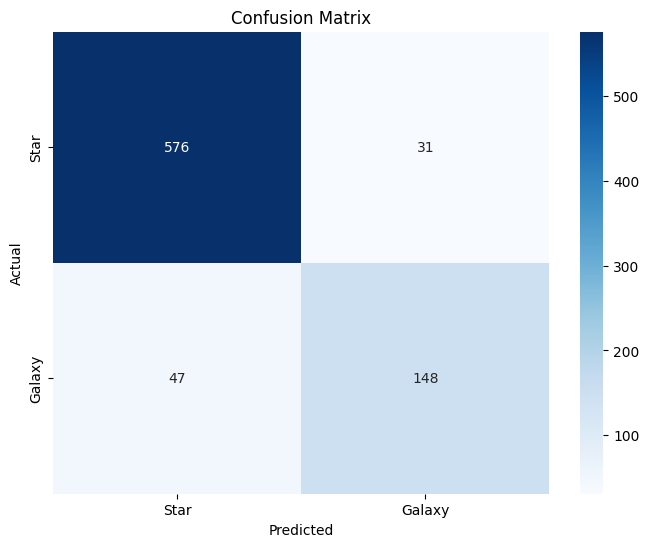

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix # Importar as métricas
import seaborn as sns # Para visualizar a matriz de confusão
import matplotlib.pyplot as plt # Para exibir o plot

# Número de camadas ocultas e tamanho (neurônios por camada)
n_camadas = 3            # número de camadas ocultas
n_neuronios = 32         # neurônios em cada camada oculta

# Dados de entrada (X) e saída (y) - Ajustando para a CNN
# Adiciona uma dimensão de canal (para tons de cinza) e remodela para 2D (altura, largura)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1).view(-1, 1, 64, 64)
y_train_tensor = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32).unsqueeze(1).view(-1, 1, 64, 64)
y_val_tensor = torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1).view(-1, 1, 64, 64)
y_test_tensor = torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32)

# MultiLayer Perceptron (MLP)
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, n_layers):
        super(MLP, self).__init__()

        layers = []
        in_features = input_size

        for i in range(n_layers):
            layers.append(nn.Linear(in_features, hidden_size))
            layers.append(nn.ReLU())
            in_features = hidden_size

        layers.append(nn.Linear(in_features, output_size))
        layers.append(nn.Sigmoid())

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Convolutional Neural Network
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Add a fourth convolutional layer
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.relu4 = nn.ReLU()
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)


        # The input size to the linear layer needs to be calculated based on the output of pooling
        # For a 64x64 input image:
        # After conv1 (padding 1, stride 1): 64x64
        # After pool1 (kernel 2, stride 2): 32x32
        # After conv2 (padding 1, stride 1): 32x32
        # After pool2 (kernel 2, stride 2): 16x16
        # After conv3 (padding 1, stride 1): 16x16
        # After pool3 (kernel 2, stride 2): 8x8
        # After conv4 (padding 1, stride 1): 8x8
        # After pool4 (kernel 2, stride 2): 4x4
        self.fc = nn.Linear(128 * 4 * 4, 1) # Corrected input size to the linear layer
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = self.relu3(x)
        x = self.pool3(x)

        # Add the fourth convolutional layer
        x = self.conv4(x)
        x = self.relu4(x)
        x = self.pool4(x)

        x = x.view(x.size(0), -1) # Flatten the output for the linear layer
        x = self.fc(x)
        x = self.sigmoid(x)
        return x


# Instância do MLP
# model = MLP(input_size=4096, hidden_size=n_neuronios, output_size=1, n_layers=n_camadas)

# Instância da CNN
model = CNN().to(device)

loss_fn = nn.BCELoss() # Função loss escolhida: Binary Cross Entropy
#optimizer = optim.SGD(model.parameters(), lr=0.1) # Optmizer escolhido: Standard Gradient Descent
optimizer = optim.Adam(model.parameters(), lr=0.001) # Optmizer escolhido: Adam

# Early Stopping parameters
patience = 20  # Número de épocas sem mudança na loss até parar
min_delta = 0.001  # Variação mínima na loss para ser considerada como melhoria
best_loss = float('inf')
epochs_no_improve = 0
best_model_state = None # Variable to store the best model state

# Treinamento do modelo
for epoch in range(500): # Definindo um número máximo de épocas
    X_train_tensor = X_train_tensor.to(device)
    y_train_tensor = y_train_tensor.to(device)
    model.train()
    optimizer.zero_grad()                   # zerar gradientes
    output = model(X_train_tensor)          # passar dados pela rede
    loss = loss_fn(output, y_train_tensor) # calcular perda
    loss.backward()                         # calcular gradientes
    optimizer.step()                        # atualizar pesos

    # Evaluation conjunto de validação
    model.eval()
    with torch.no_grad():
        X_val_tensor = X_val_tensor.to(device)
        y_val_tensor = y_val_tensor.to(device)
        val_output = model(X_val_tensor)
        val_loss = loss_fn(val_output, y_val_tensor)

    if (epoch + 1) % 10 == 0: # Imprime a loss a cada 10 épocas
        print(f"Epoch {epoch+1}, Training Loss: {loss.item():.4f}, Validation Loss: {val_loss.item():.4f}")

    # Early stopping
    if val_loss < best_loss - min_delta:
        best_loss = val_loss
        epochs_no_improve = 0
        best_model_state = model.state_dict().copy() # Save the best model state
    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Load the best model state before final evaluation
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("Loaded best model state based on validation loss.")

# Avaliação final no conjunto de teste
model.eval()
with torch.no_grad():
    X_test_tensor = X_test_tensor.to(device)
    y_test_tensor = y_test_tensor.to(device)
    y_pred = model(X_test_tensor)
    y_pred_labels = (y_pred > 0.5).float()

    accuracy = (y_pred_labels == y_test_tensor).float().mean()
    print(f"Acurácia no teste: {accuracy}")

    # Calcular e imprimir Precision, Recall e F1-score
    precision = precision_score(y_test_tensor.cpu().numpy(), y_pred_labels.cpu().numpy())
    recall = recall_score(y_test_tensor.cpu().numpy(), y_pred_labels.cpu().numpy())
    f1 = f1_score(y_test_tensor.cpu().numpy(), y_pred_labels.cpu().numpy())

    print(f"Precision no teste: {precision:.4f}")
    print(f"Recall no teste: {recall:.4f}")
    print(f"F1-score no teste: {f1:.4f}")

    # Calcular e exibir a matriz de confusão
    cm = confusion_matrix(y_test_tensor.cpu().numpy(), y_pred_labels.cpu().numpy())
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Star', 'Galaxy'], yticklabels=['Star', 'Galaxy'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

Number of misclassified images: 77
Image: rotated_J1530p2310_r_01_42_859_3.jpg, Actual: Galaxy, Predicted: Star


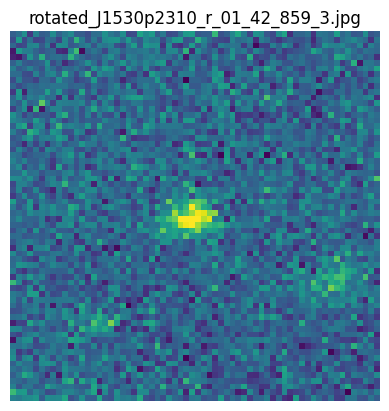

Image: rotated_J125219p264053_001_010_578_1739_3.jpg, Actual: Galaxy, Predicted: Star


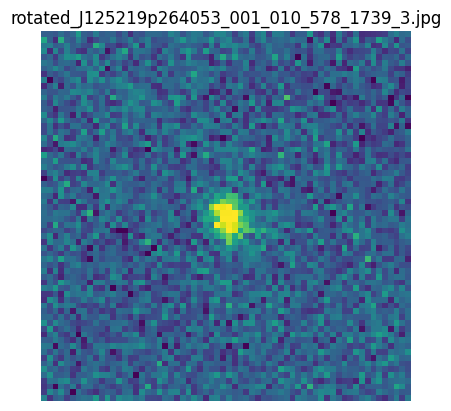

Image: rotated_UM439-H01_528_1048_6.jpg, Actual: Star, Predicted: Galaxy


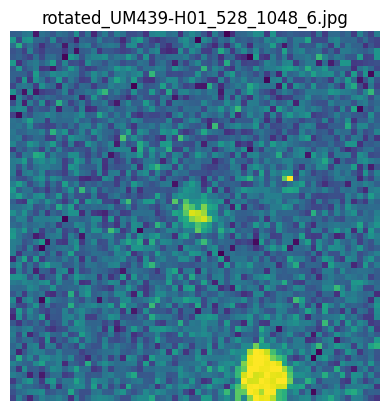

Image: j1612p5118_r_01_339_1340_3.jpg, Actual: Galaxy, Predicted: Star


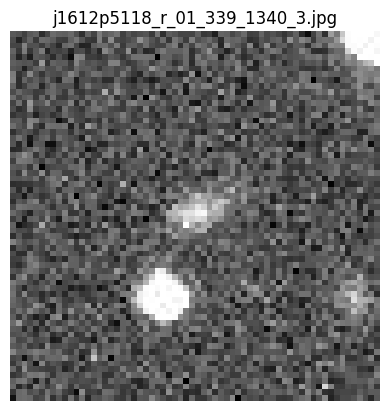

Image: J142943p385931_001_001_1644_1013_3.jpg, Actual: Galaxy, Predicted: Star


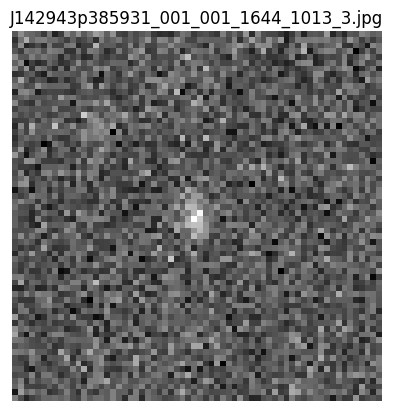

Image: flipped_J161245p511816_001_010_887_1247_3.jpg, Actual: Galaxy, Predicted: Star


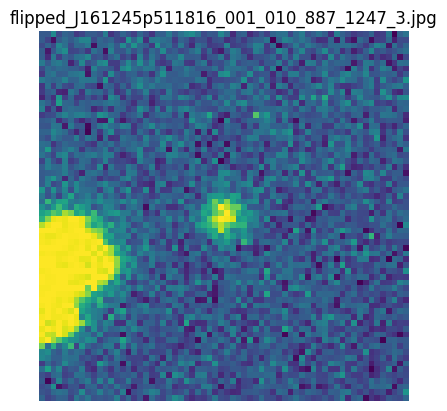

Image: J1603p3002_001_010_894_1250_3.jpg, Actual: Galaxy, Predicted: Star


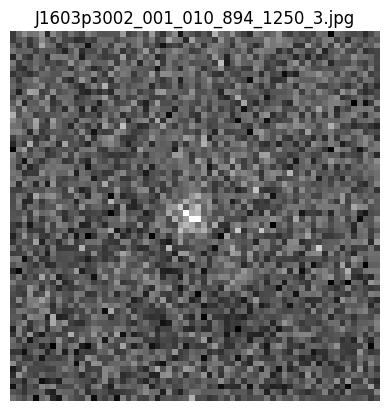

Image: flipped_J1603p3002_001_010_138_292_3.jpg, Actual: Galaxy, Predicted: Star


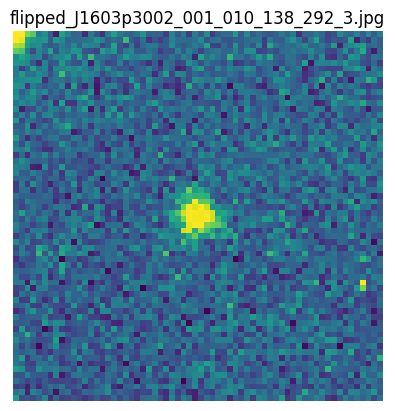

Image: J125219p264053_001_010_1315_484_6.jpg, Actual: Star, Predicted: Galaxy


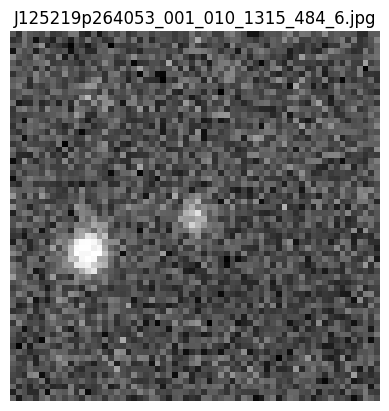

Image: flipped_j1612p5118_r_01_1845_1193_3.jpg, Actual: Galaxy, Predicted: Star


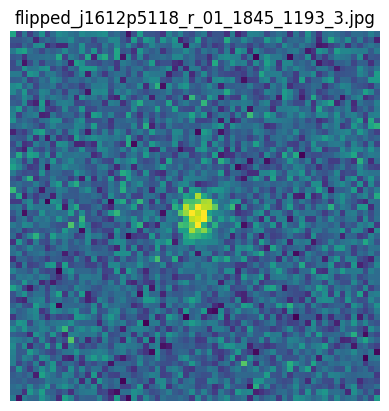

In [ ]:
# Identify misclassified images
misclassified_indices = torch.where(y_pred_labels != y_test_tensor)[0]
misclassified_image_names = X_test_copy[misclassified_indices.cpu().numpy()]
misclassified_labels_actual = y_test_tensor[misclassified_indices].cpu().numpy()
misclassified_labels_predicted = y_pred_labels[misclassified_indices].cpu().numpy()

print(f"Number of misclassified images: {len(misclassified_image_names)}")

# Display a few misclassified images
num_images_to_show = 10
for i in range(min(num_images_to_show, len(misclassified_image_names))):
    image_name = misclassified_image_names[i]
    actual_label = "Galaxy" if misclassified_labels_actual[i] == 1 else "Star"
    predicted_label = "Galaxy" if misclassified_labels_predicted[i] == 1 else "Star"
    print(f"Image: {image_name}, Actual: {actual_label}, Predicted: {predicted_label}")
    show(image_name)